In [3]:
import jax, sys
import jax.numpy as jnp
sys.path.append('../../src')
from sweep.propagator.jax import PropJax
from sweep.equations import Acoustic
from sweep.signal import ricker
import numpy as np
import matplotlib.pyplot as plt

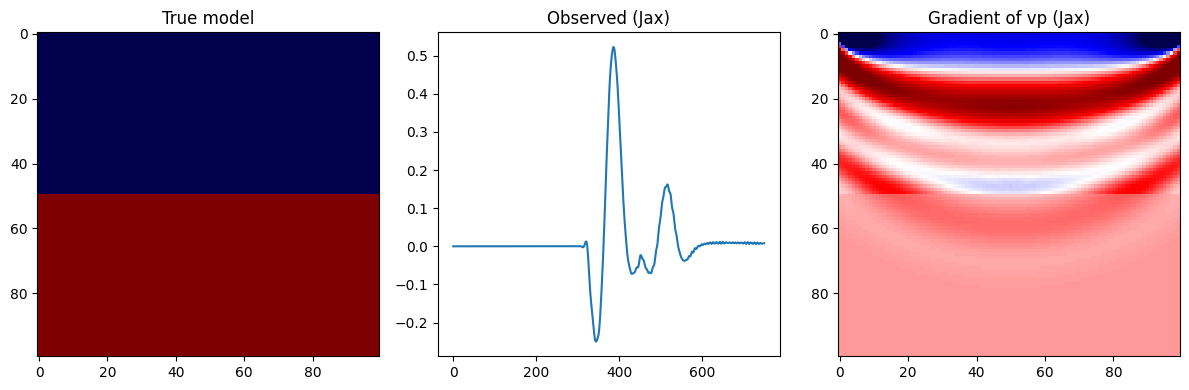

In [5]:
# Model parameters
nt = 1500
dt = 0.002
dh = 10
delay = 0.1
fm = 5
spatial_order = 8
shape = (100,100)


# Create a 2-layer velocity model
true_model = np.ones(shape, dtype=np.float32)*1500
true_model[50:, :] = 2000

eq_kwargs = dict(spatial_order=spatial_order, device=None)
solver_kwargs = dict(shape=shape, dev=None, dh=dh, dt=dt, source_type=['h1'], receiver_type=['h1'], abcn=30, free_surface=False, pml_type='cpmlr', use_ckpt=False)
# Create a solver_torch
solver_jax = PropJax(Acoustic(**eq_kwargs, backend='jax'), **solver_kwargs)

# Set the solver_jax parameters (Jax)
solver_jax.set_parameters([jnp.array(true_model)])

# Create a wavelet
t = np.arange(0, int(nt//2)*dt, dt)
wave = ricker(t-delay, f=fm)

# Acquicition geometry
sources = np.array([[1, 1]]) # in grid, shape=(nshots, 2)
receivers = np.array([[[99, 1]]]) # in grid, shape=(nshots, nreceivers, 2)

obs = solver_jax(wave, sources, receivers, models=[jnp.array(true_model)])
# Forward modeling
# Backward propagation (Jax)
def fwi(vp):
    return (solver_jax(wave, sources, receivers, models=[vp])**2).sum()
grad_jax = jax.grad(fwi)(solver_jax.vp)

# Show the results
fig, axes=plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(true_model, cmap='seismic', aspect='auto')
axes[0].set_title('True model')

axes[1].plot(obs.squeeze(), label='Observed data')

vmin,vmax=np.percentile(grad_jax, [1,99])
axes[1].set_title('Observed (Jax)')
axes[2].imshow(grad_jax, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
axes[2].set_title('Gradient of vp (Jax)')
fig.tight_layout()
plt.show()